# **Credit Card Fraud Detection Detecting Fraudulent Transactions Using Machine Learning**

*   **Author**: Sisilia Manullang
*   **Dataset**: Credit Card Fraud Detection by ULB Machine Learning Group (Kaggle)
*   **Tools**: Python, Pandas, Scikit-learn, XGBoost, SHAP, SMOTE

## **1. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Data Loading & Definition**

**Note:** Untuk menjalankan notebook ini, tambahkan Kaggle API credentials anda:
- KAGGLE_USERNAME: your kaggle username
- KAGGLE_KEY: API token from kaggle.com/settings

In [3]:
!pip install kaggle -q
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 81.9MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


## **3. Exploratory Data Analysis (EDA)**

In [4]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### **3.1 Class Distribution**

In [6]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


**INSIGHT**

Berdasarkan analisis, dari seluruh **284.807** total transaksi dengan tanpa missing value,  terdapat 284315 transaksi normal, namun terdapat 492 transaksi, 0.17% transaksi fraud darti total keseluruhan transaksi, yang berarti dataset ini sangat imbalance. Hal ini dapat berdampak, Ketika model tanpa dilatih apapun, dapat selalu klaim transaksi normal bahkan pada transaksi fraud, bahkan akurasi yang didapatkan bisa mencapai 99,8%. Oleh karena itu, accuracy bukan metrik yang tepat untuk kasus ini. Kita perlu metrik yang lebih sensitif terhadap kelas minoritas seperti recall, precision, dan F1 score. Pada case ini, maka metrik recall lebih diprioritaskan, hal ini disebabkan dampak fraud yang lolos lebih destruktif dari sisi bisnis karena dapat menyebabkan kerugian yang lebih besar akibat dari churn pelanggan yang complain. Meskipun Precision yang rendah juga berdampak pada churn akibat transaksi normal yang salah diblokir, dampak Recall yang rendah jauh lebih besar karena berpotensi viral, merusak reputasi bank, dan menyebabkan mass churn yang merugikan ratusan juta rupiah per tahun.

### **3.2 Amount Distribution**

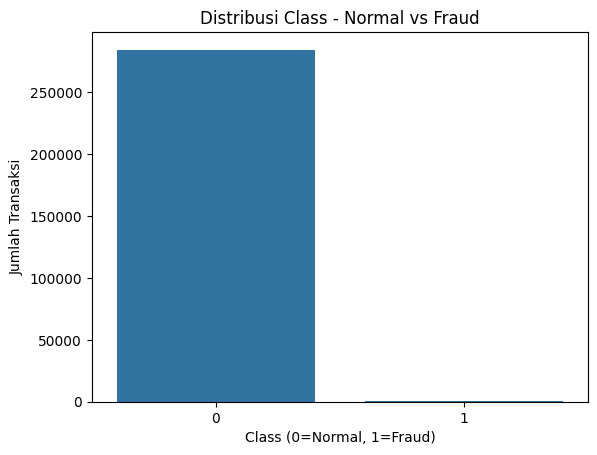

In [7]:
sns.countplot(x='Class', data=df)
plt.title('Distribusi Class - Normal vs Fraud')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Jumlah Transaksi')
plt.show()

**INSIGHT**

Pada grafik tersebut dapat dilihat  perbandingan yang sangat besar pada kedua transaksi, dimana transaksi normal jauh lebih banyak daripada transaksi fraud yang sekitar 0,17% dari seluruh transaksi yang dilakukan. Kondisi ini perlu ditangani sebelum modeling agar model tidak bias terhadap kelas mayoritas yang menyebabkan transaksi fraud akan diklaim normal bahkan dengan akurasi 99.8%.

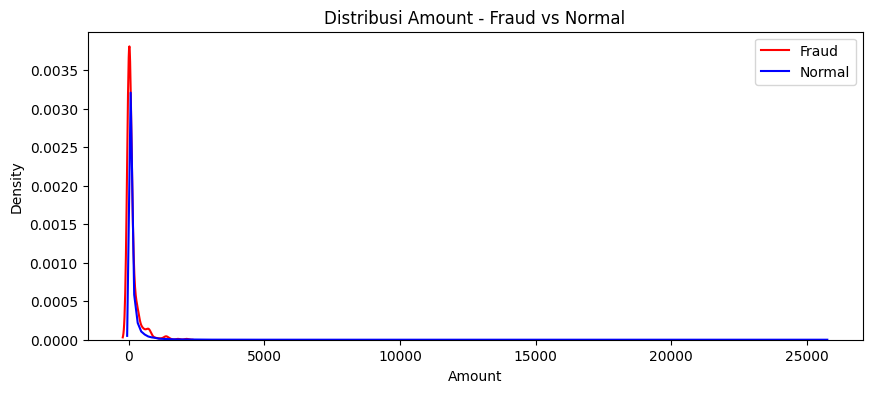

In [8]:
fraud = df[df['Class'] == 1]['Amount']
normal = df[df['Class'] == 0]['Amount']

plt.figure(figsize=(10, 4))
sns.kdeplot(fraud, label='Fraud', color='red')
sns.kdeplot(normal, label='Normal', color='blue')
plt.title('Distribusi Amount - Fraud vs Normal')
plt.xlabel('Amount')
plt.legend()
plt.show()

**INSIGHT**

Berdasarkan visualisasi distribusi Amount, transaksi fraud terkonsentrasi di nominal yang sangat kecil mendekati nol, sementara transaksi normal tersebar hingga nominal yang jauh lebih besar. Hal ini konsisten dengan pola probing transaction, dimana pelaku fraud sengaja memulai dengan transaksi kecil untuk menguji apakah kartu masih aktif dan apakah korban menyadari adanya transaksi mencurigakan. Bank perlu mewaspadai transaksi dengan nominal sangat kecil yang terjadi berulang dalam waktu singkat, karena pola ini berpotensi menjadi indikator awal aktivitas fraud sebelum pelaku melakukan transaksi dalam jumlah besar.

### **3.3 Correlation Analysis**

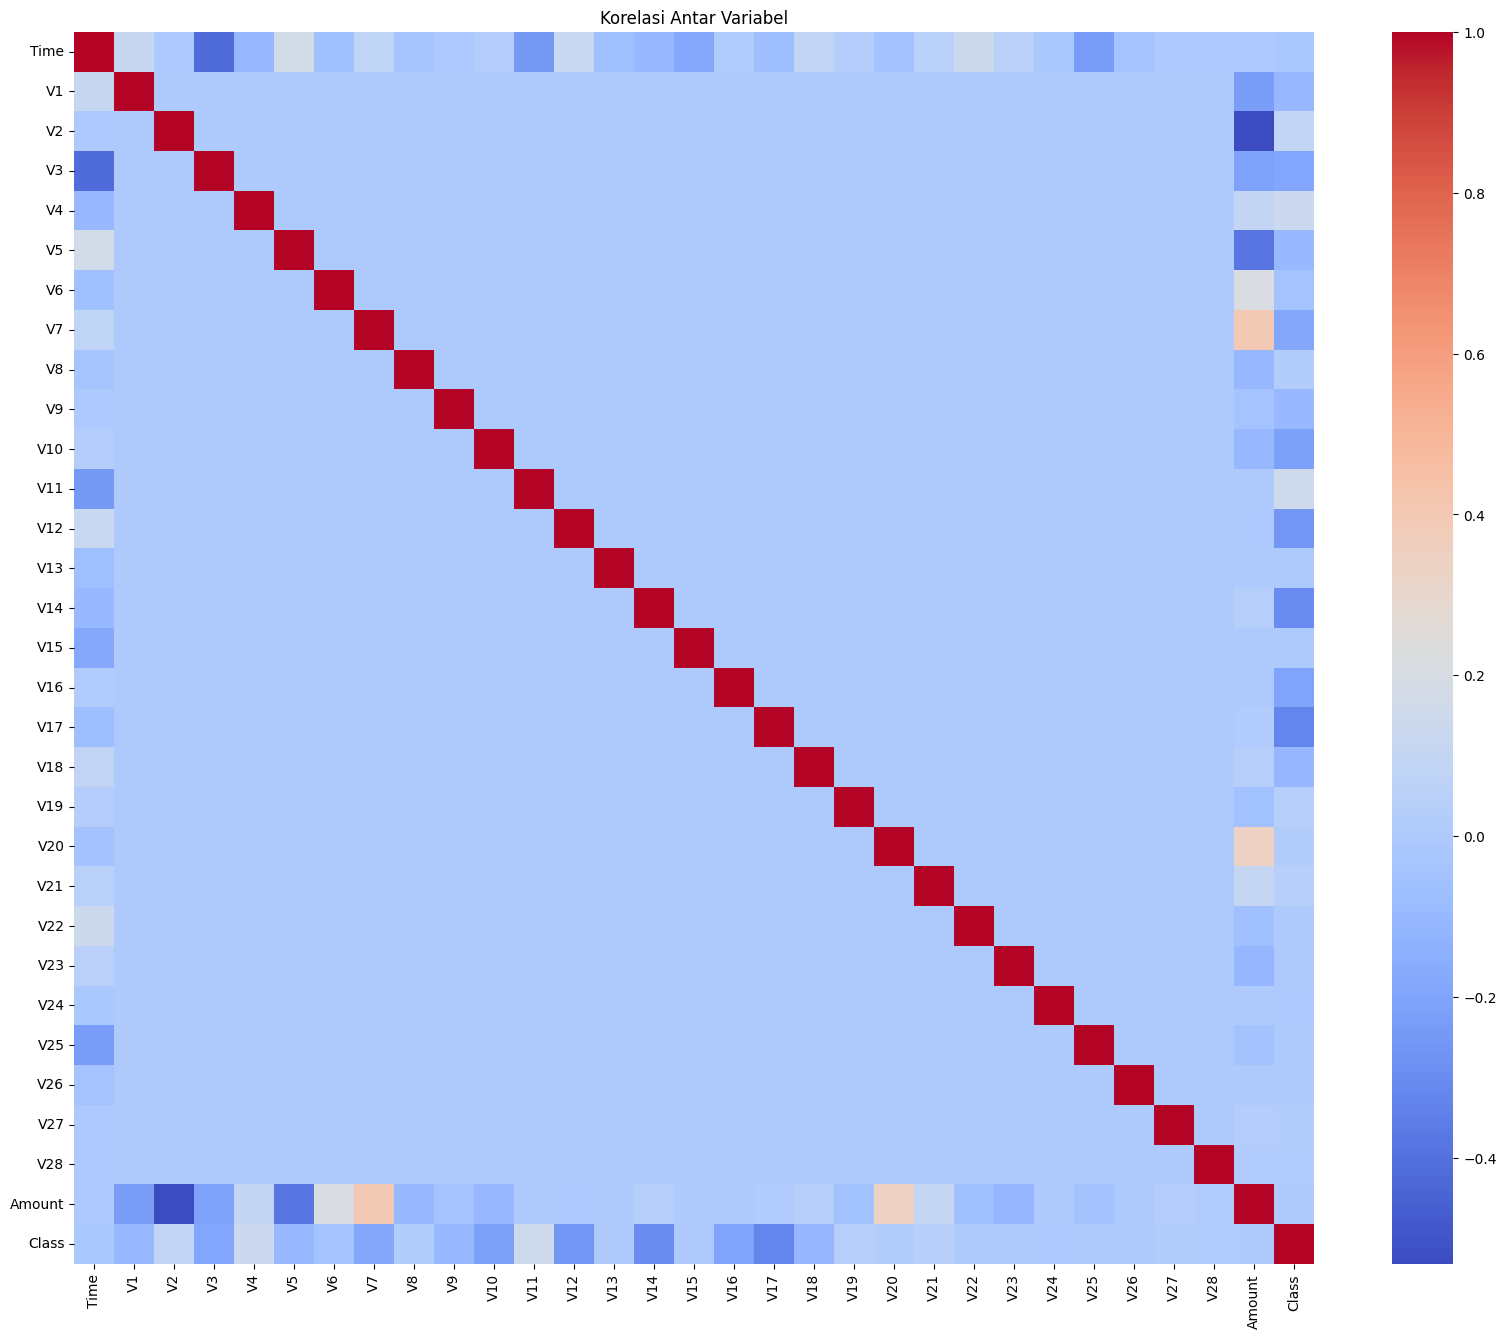

In [9]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Korelasi Antar Variabel')
plt.show()

In [10]:
df.corr()['Class'].sort_values()

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


**INSIGHT**

Berdasarkan analisis korelasi antara seluruh variabel dengan kolom Class, dapat dilihat pada heatmap bahwa V17 memiliki korelasi yang paling negative yaitu dengan nilai -0.326481, ini mengindikasikan V17 berlawanan arah dengan Class, yang mana berarti semakin tinggi nilai V17, semakin kecil kemungkinan transaksi itu fraud. Jadi V17 bisa jadi indikator transaksi normal. Sebaliknya, V11 menunjukkan korelasi yang paling positif yaitu dengan nilai 0.154876, ini mengindikasikan semakin tinggi nilai V11, semakin besar kemungkinan transaksi itu fraud. Jadi V11 adalah salah satu fitur yang paling berguna untuk mendeteksi fraud.

### **3.4 Time Pattern Analysis**

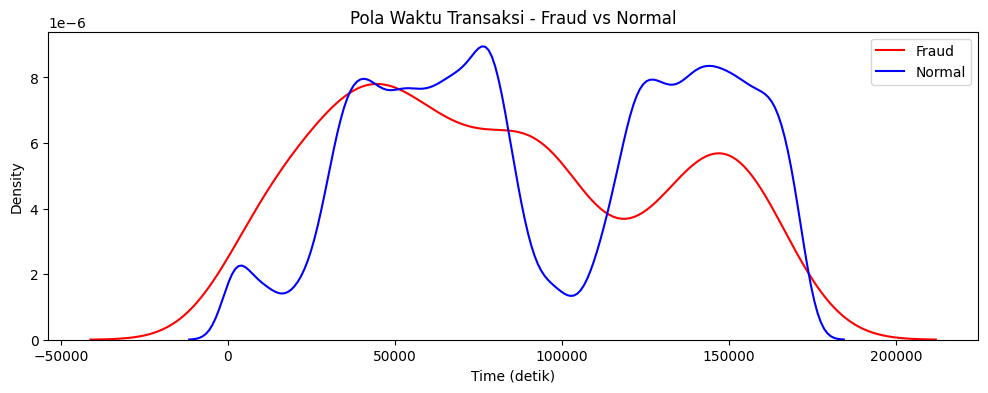

In [11]:
fraud_time = df[df['Class'] == 1]['Time']
normal_time = df[df['Class'] == 0]['Time']

plt.figure(figsize=(12, 4))
sns.kdeplot(fraud_time, label='Fraud', color='red')
sns.kdeplot(normal_time, label='Normal', color='blue')
plt.title('Pola Waktu Transaksi - Fraud vs Normal')
plt.xlabel('Time (detik)')
plt.legend()
plt.show()

**INSIGHT**

Berdasarkan grafik visualisasi di atas, dapat dilihat bahwa garis biru (normal) dan garis merah (fraud) memiliki pola yang hamper serupa. Ini artinya, pelaku fraud menyamarkan transaksinya di tengah aktivitas normal supaya tidak mencurigakan. Ini disebut camouflage behavior, dimana pelaku sengaja melakukan fraud saat volume transaksi normal sedang tinggi, karena di tengah ribuan transaksi normal, fraud lebih sulit terdeteksi secara manual. Di sisi lain, pada grafik dapat dilihat,  garis merah (fraud) lebih smooth/halus dibanding garis biru (normal) yang naik turun tajam. Ini berarti, garis biru (normal) naik turun tajam artinya transaksi normal punya pola yang jelas, dimana ada jam ramai, ada jam sepi. Seperti pola belanja orang pada umumnya. Garis merah (fraud) lebih smooth artinya fraud terjadi lebih merata sepanjang Waktu, dimana tidak terlalu terpengaruh jam ramai atau sepi. Hal ini menunjukkan bahwa deteksi fraud tidak bisa hanya mengandalkan pola Waktu, dibutuhkan pendekatan yang lebih sophisticated.

## **4. Data Preprocessing**

### **4.1 Train-Test Split**

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (227845, 30)
X_test: (56962, 30)


### **4.2 Handling Class Imbalance (SMOTE)**

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Sebelum SMOTE: {y_train.value_counts()}')
print(f'Setelah SMOTE: {y_train_smote.value_counts()}')

Sebelum SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
Setelah SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


**INSIGHT**

Sebelum SMOTE diterapkan, jumlah transaksi fraud di train set hanya 394 berbanding 227.451 transaksi normal, kondisi yang sangat tidak seimbang. Untuk mengatasi hal ini, SMOTE (Synthetic Minority Oversampling Technique) digunakan untuk membuat data sintetis baru yang mirip dengan data fraud yang ada, bukan sekadar menduplikasi data yang sudah ada. Hasilnya, jumlah fraud di train set meningkat menjadi 227.451, seimbang dengan data normal. Perlu dicatat bahwa SMOTE hanya diterapkan pada train set, bukan test set, karena test set harus mencerminkan kondisi nyata.

### **4.3 Feature Scaling**

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

**INSIGHT**

Sebelum melakukan modelling, perlu dilakukan scaling terlebih dahulu mengingat kolom amount nilainya bisa sampai 25.000 lebih, sementara kolom V1-V28 nilainya kecil-kecil antara -5 sampai 5. Scaling perlu dilakukan, untuk menghindari model menjadi bias, dimana model akan menganggap kolom Amount lebih penting dari kolom lain hanya karena nilainya lebih besar. Padahal belum tentu Amount yang paling menentukan fraud atau tidak. Pada case ini menggunakan StandardScaler untuk mengubah semua nilai menjadi skala yang sama dengan rata-rata 0 dan standar deviasi 1. Pada train_set dilakukan fit_transform untuk mengukur dulu rata-rata dan standar deviasinya, kemudian transform di test_set untuk menggunakan ukuran yang sudah dihitung dari train set tanpa mengukur ulang.

## **5. Modeling**


### **5.1 Logistic Regression**

In [15]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train_scaled, y_train_smote)

print("Model Logistic Regression selesai dilatih!")

Model Logistic Regression selesai dilatih!


In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



### **5.2 Random Forest**

In [17]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42, n_estimators=100)
model_rf.fit(X_train_scaled, y_train_smote)

print("Model Random Forest selesai dilatih!")

Model Random Forest selesai dilatih!


In [18]:
y_pred_rf = model_rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



**INSIGHT**

Setelah dibandingkan menggunakan metrik precision, recall, dan f1 score, Logistic Regression memiliki precision yang sangat rendah untuk transaksi fraud yaitu dengan nilai 0.13 yang artinya dari 100 transaksi yang dituduh fraud, hanya 13 yang benar-benar fraud dan 87 nasabah tidak bersalah ikut diblokir. Setelah menggunakan model Random Forest, nilai dari precision naik untuk transaksi fraud yaitu dengan nilai 0.84 yang artinya dari 100 transaksi yang dituduh fraud, hanya 84 yang benar-benar fraud dan 16 nasabah tidak bersalah ikut diblokir. Untuk bank yang mengutamakan keamanan nasabah, disarankan mengoptimalkan Recall. Namun untuk menjaga pengalaman nasabah tetap baik, Random Forest dengan F1-Score 0.83 memberikan keseimbangan yang lebih baik. Meskipun Recall Random Forest sedikit lebih rendah dari Logistic Regression (0.83 vs 0.90), artinya ada sedikit lebih banyak fraud yang lolos, namun lebih sedikit nasabah tidak bersalah yang diblokir.

**KESIMPULAN MODEL**

Proyek ini bertujuan untuk mendeteksi transaksi kartu kredit yang fraudulent menggunakan machine learning. Tantangan utama dataset ini adalah class imbalance yang ekstrem dimana hanya 0.17% transaksi yang fraud yang menyebabkan accuracy tidak dapat dijadikan metrik evaluasi yang reliable. Untuk mengatasi hal ini, SMOTE diterapkan untuk menyeimbangkan data training sebelum modeling. Setelah membandingkan dua model, Random Forest terbukti lebih unggul dibanding Logistic Regression dengan F1-Score 0.83 vs 0.23 untuk kelas fraud. Model ini direkomendasikan untuk diimplementasikan bank karena memberikan keseimbangan yang baik antara mendeteksi fraud dan meminimalkan gangguan pada nasabah yang bertransaksi normal.

### **6.1 Confusion Matrix**

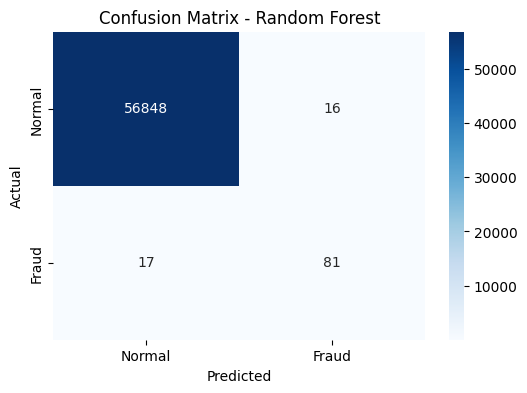

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**INSIGHT**

Berdasarkan Confusion Matrix Random Forest, dari 98 total transaksi fraud di test set, model berhasil mendeteksi 81 fraud (True Positive) dan melewatkan 17 fraud (False Negative). Artinya model menangkap 82.6% transaksi fraud, ini adalah skenario yang paling berbahaya bagi bank karena 17 nasabah berpotensi mengalami kerugian tanpa sepengetahuan mereka. Di sisi lain, hanya 16 transaksi normal yang salah diblokir (False Positive) dari 56.864 transaksi normal, dimana ini angka yang sangat kecil dan tidak terlalu mengganggu pengalaman nasabah. Secara keseluruhan, Random Forest menunjukkan performa yang baik dengan meminimalkan kesalahan di kedua sisi.

### **6.2 ROC-AUC Curve**

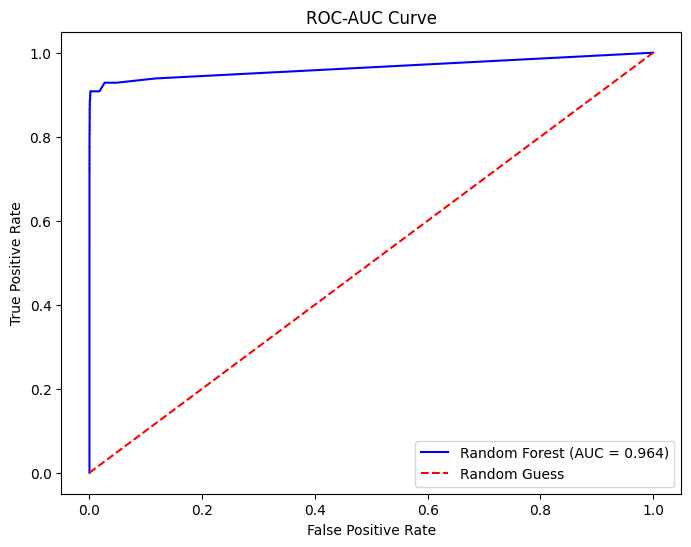

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model_rf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
plt.title('ROC-AUC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**INSIGHT**

Berdasarkan ROC-AUC Curve, garis biru (Random Forest) bergerak tajam ke pojok kiri atas dengan False Positive Rate yang sangat kecil, artinya model mampu mendeteksi hampir semua fraud tanpa banyak memblokir transaksi normal yang tidak bersalah. Dengan AUC = 0.964, model ini 96.4% lebih baik dibanding tebak-tebakan (garis merah), yang mengkonfirmasi bahwa Random Forest adalah model yang sangat handal untuk mendeteksi fraud dalam dataset ini.

### **6.3 Feature Importance**

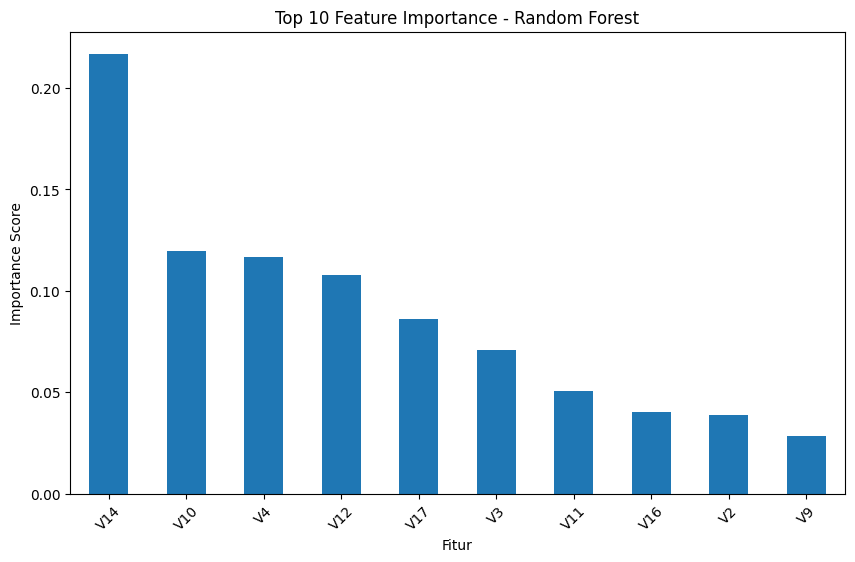

In [21]:
feat_importance = pd.Series(
    model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)[:10]

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='bar')
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Fitur')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.show()

**INSIGHT**

Berdasarkan analisis Feature Importance, V14 merupakan fitur paling berpengaruh dengan importance score 0.21, artinya model paling sering menggunakan V14 sebagai dasar keputusan dalam mendeteksi fraud. Sementara V9 merupakan fitur paling tidak berpengaruh dari top 10. Namun karena seluruh fitur telah dianonimkan menggunakan PCA, interpretasi mendalam terhadap makna asli fitur-fitur tersebut tidak dapat dilakukan. Untuk penelitian selanjutnya, disarankan menggunakan SHAP values guna menjelaskan keputusan model secara lebih transparan dan interpretatif.

###**6.4 Cross Validation**

In [22]:
avg_fraud_amount = df[df['Class'] == 1]['Amount'].mean()
print(f'Rata-rata nominal transaksi fraud: ${avg_fraud_amount:.2f}')

Rata-rata nominal transaksi fraud: $122.21


In [23]:
total_saved = 81 * avg_fraud_amount
total_missed = 17 * avg_fraud_amount

print(f'Estimasi kerugian yang berhasil dicegah: ${total_saved:,.2f}')
print(f'Estimasi kerugian yang masih lolos: ${total_missed:,.2f}')
print(f'Persentase kerugian berhasil dicegah: {81/98*100:.1f}%')

Estimasi kerugian yang berhasil dicegah: $9,899.12
Estimasi kerugian yang masih lolos: $2,077.59
Persentase kerugian berhasil dicegah: 82.7%


**INSIGHT**

Dari 56.962 transaksi di test set, model Random Forest berhasil mencegah kerugian sebesar $9,899 atau 82.7% dari total potensi kerugian fraud. Sementara $2,077 masih lolos akibat 17 transaksi fraud yang tidak terdeteksi, angka yang perlu ditingkatkan di iterasi berikutnya melalui hyperparameter tuning atau model yang lebih advanced seperti XGBoost.

In [24]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_rf,
    X_train_scaled,
    y_train_smote,
    cv=5,
    scoring='recall'
)

print(f'Recall per fold: {cv_scores}')
print(f'Rata-rata Recall: {cv_scores.mean():.3f}')
print(f'Standar Deviasi: {cv_scores.std():.3f}')

Recall per fold: [0.99993405 1.         1.         1.         1.        ]
Rata-rata Recall: 1.000
Standar Deviasi: 0.000


**INSIGHT**

Berdasarkan 5-Fold Cross Validation, model Random Forest menghasilkan rata-rata Recall 1.000 dengan standar deviasi 0.000 pada data training. Namun ketika dievaluasi pada test set, Recall turun menjadi 0.83, dimana ini menunjukkan perbedaan yang cukup signifikan. Hal ini mengindikasikan adanya overfitting, dimana model terlalu hafal pola data training (yang sudah di-SMOTE) namun performanya menurun pada data nyata. Untuk mengatasi overfitting ini, disarankan melakukan hyperparameter tuning pada Random Forest di iterasi selanjutnya.

###**6.5 Hyperparameter Tuning**

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_smote)
print(f'Parameter terbaik: {grid_search.best_params_}')
print(f'Recall terbaik: {grid_search.best_score_:.3f}')

Parameter terbaik: {'max_depth': None, 'n_estimators': 100}
Recall terbaik: 1.000


In [26]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



**INSIGHT**

Hasil GridSearchCV menunjukkan parameter terbaik adalah n_estimators=100 dan max_depth=None, yang identik dengan model Random Forest awal. Hal ini mengkonfirmasi bahwa model awal sudah optimal dan tidak memerlukan tuning tambahan untuk dataset ini.

### **6.6 Advanced Model - XGBoost**

In [27]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_estimators=100
)

model_xgb.fit(X_train_scaled, y_train_smote)
print("Model XGBoost selesai dilatih!")

Model XGBoost selesai dilatih!


In [28]:
y_pred_xgb = model_xgb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.86      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962



**INSIGHT**

Perbandingan tiga model menunjukkan bahwa XGBoost dan Random Forest memiliki F1-Score yang sama yaitu 0.83, namun dengan trade-off yang berbeda. XGBoost unggul dalam Recall (0.86 vs 0.83), artinya lebih banyak fraud yang berhasil ditangkap. Sementara Random Forest unggul dalam Precision (0.84 vs 0.81), artinya lebih sedikit transaksi normal yang salah diblokir. Untuk bank yang mengutamakan keamanan nasabah, XGBoost lebih direkomendasikan karena Recall yang lebih tinggi berarti lebih sedikit fraud yang lolos.

### **6.7 SHAP Values**

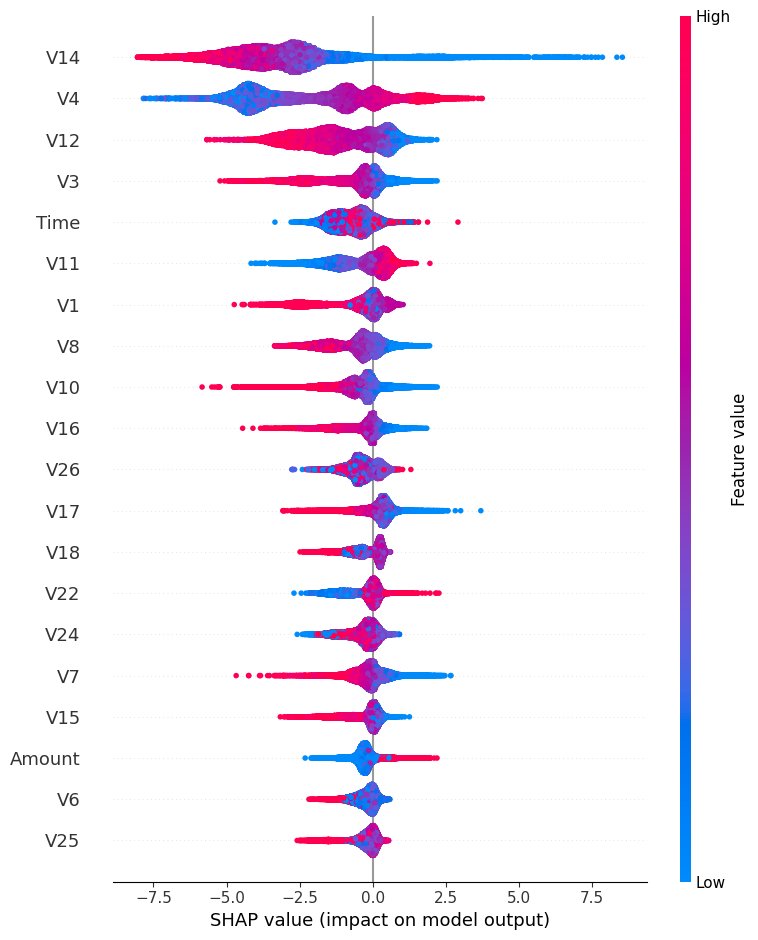

In [29]:
import shap

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  show=True)

**INSIGHT**

Berdasarkan SHAP Summary Plot, V14 merupakan fitur paling berpengaruh dalam prediksi model XGBoost. Nilai V14 yang tinggi (merah) mendorong prediksi ke arah fraud, sementara nilai rendah (biru) mendorong ke arah normal. Hal ini konsisten dengan hasil Feature Importance pada Random Forest sebelumnya. Selain V14, fitur V4, V12, dan V3 juga memiliki pengaruh signifikan terhadap keputusan model. SHAP values memberikan transparansi pada model, memungkinkan bank untuk memahami alasan di balik setiap prediksi fraud secara individual.

## **7. Business Impact & Conclusion**

### **7.1 Kesimpulan**

1. Proyek ini bertujuan mendeteksi transaksi kartu kredit yang fraudulent menggunakan pendekatan machine learning. Dari total 284.807 transaksi, hanya 0.17% yang merupakan fraud, menciptakan tantangan class imbalance yang ekstrem sehingga accuracy tidak dapat dijadikan metrik evaluasi yang andal.

2. Melalui eksplorasi data, ditemukan dua pola perilaku fraud yang signifikan. Pertama, probing transaction, dimana pelaku memulai dengan transaksi bernilai sangat kecil mendekati nol untuk menguji apakah kartu aktif dan apakah korban menyadarinya. Kedua, camouflage behavior, dimana pelaku melakukan fraud saat volume transaksi normal sedang tinggi untuk menghindari deteksi manual.

3. Setelah membandingkan tiga model, Random Forest dan XGBoost menunjukkan performa terbaik dengan F1-Score 0.83, jauh melampaui Logistic Regression yang hanya 0.23. XGBoost sedikit lebih unggul dalam Recall (0.86 vs 0.83), artinya lebih banyak fraud berhasil ditangkap. Sementara Random Forest lebih unggul dalam Precision (0.84 vs 0.81), artinya lebih sedikit nasabah tidak bersalah yang terdampak.

### **7.2 Rekomendasi Bisnis**

1. Untuk bank yang mengutamakan keamanan nasabah, XGBoost direkomendasikan karena Recall yang lebih tinggi memastikan lebih sedikit fraud yang lolos. Model ini berhasil mencegah kerugian sebesar $9.899 atau 82.7% dari total potensi kerugian fraud dalam test set. Pada skala operasional yang lebih besar, penerapan model ini berpotensi mencegah kerugian ratusan ribu dolar per tahun.

2. Untuk penelitian selanjutnya, disarankan mengimplementasikan SHAP values secara real-time untuk memberikan transparansi kepada nasabah mengenai alasan pemblokiran transaksi, serta melakukan hyperparameter tuning XGBoost dan eksplorasi model ensemble untuk meningkatkan performa lebih lanjut.